In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, \
                  array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import seaborn as sns
import scipy.cluster.hierarchy
from scipy.spatial.distance import squareform
import sklearn
from sklearn.decomposition import PCA
import itertools
import mdtraj as md
from __future__ import print_function

In [2]:
pdb='/data/Jayde/Rega/Ligand/production2us.pbcstruc.gro'
trajectory='/data/Jayde/Rega/Ligand/production2us.pbctraj.xtc'
outdir='/data/Jayde/Rega/Ligand/HBond_Analysis/'

if not os.path.exists('outdir'):
    os.makedirs('outdir')
    
print("outdir:",outdir)
print("pdb:",pdb)
print("trajectory:",trajectory)

outdir: /data/Jayde/Rega/Ligand/HBond_Analysis/
pdb: /data/Jayde/Rega/Ligand/production2us.pbcstruc.gro
trajectory: /data/Jayde/Rega/Ligand/production2us.pbctraj.xtc


In [3]:
trj = md.load(trajectory, top=pdb,stride=1)
trj.center_coordinates()
top = trj.topology
first_frame = 0
last_frame = trj.n_frames
n_frames=trj.n_frames

In [4]:
nres=[]
for res in trj.topology.residues: nres.append(res.resSeq)
sequence=(' %s' % [residue for residue in trj.topology.residues])
resname=(' %s' % [residue.name for residue in trj.topology.residues])
resindex=(' %s' % [residue.index for residue in trj.topology.residues])
res_num=(' %s' % [residue.resSeq  for residue in trj.topology.residues])



#log = open("/Users/paulrobustelli/Desktop/Sa_calc.log", "w")
print("** SYSTEM INFO **\n")
print("Number of atoms: %d\n" % trj.n_atoms)
print("Number of residues: %d\n" % len(set(nres)))
print("Number of frames: %d\n" % trj.n_frames)
print("Starting frame: %d\n" % first_frame)
print("Last frame: %d\n" % last_frame)
print("sequence: %s\n" % sequence)
print("residue names: %s\n" % resname)
print("residue number: %s\n" % res_num)
print("residue index: %s\n" % resindex)


** SYSTEM INFO **

Number of atoms: 51351

Number of residues: 12045

Number of frames: 21001

Starting frame: 0

Last frame: 21001

sequence:  [ASN21, ASN22, MET23, LEU24, VAL25, LEU26, LYS27, LYS28, ILE29, ARG30, PHE31, TYR32, ASN33, CYS34, ALA35, ILE36, ILE37, HIS38, LEU39, ARG40, ASP41, ALA42, GLN43, LEU44, LEU45, ILE46, ARG47, THR48, LYS49, ASP50, GLY51, GLN52, THR53, LEU54, ASN55, ILE56, PRO57, PRO58, GLU59, SER60, LEU61, CYS62, TYR63, VAL64, GLU65, LYS66, ASN67, THR68, VAL69, MET70, ASP71, VAL72, ALA73, LEU74, LYS75, VAL76, LEU77, GLY78, SER79, GLY80, VAL81, PRO82, TYR83, GLU84, VAL85, TYR86, HIS87, VAL88, ASP89, SER90, ASP91, VAL92, LEU93, ARG94, CYS95, ILE96, CYS97, LYS98, VAL99, MET100, GLU101, PRO102, LEU103, LEU104, LEU105, ASP106, PRO107, GLN108, ARG109, VAL110, ASN111, HIS112, THR113, ARG114, ARG115, LYS116, ILE117, PHE118, THR119, CYS120, ALA121, VAL122, ASP123, GLU124, THR125, ASP126, THR127, ARG128, ILE129, PHE130, LYS131, ARG132, LEU133, THR134, GLY135, SER136, ASN137

In [5]:
residue_num=[]
for res in top.residues: 
    residue_num.append(res.resSeq)
residue_id=np.asarray(residue_num)
residue_id

array([   21,    22,    23, ..., 12063, 12064, 12065], shape=(12045,))

In [6]:
protein_indices = trj.topology.select('protein')
traj_protein = trj.atom_slice(protein_indices)
# del trj

In [7]:
#Use DSSP to calculate the secondary structure definition
#https://mdtraj.org/1.9.4/api/generated/mdtraj.compute_dssp.html
dssp=md.compute_dssp(traj_protein,simplified=True)
dssp

array([['C', 'C', 'E', ..., 'H', 'C', 'C'],
       ['C', 'C', 'C', ..., 'H', 'C', 'C'],
       ['C', 'C', 'C', ..., 'H', 'C', 'C'],
       ...,
       ['C', 'C', 'E', ..., 'C', 'C', 'C'],
       ['C', 'C', 'E', ..., 'C', 'C', 'C'],
       ['C', 'C', 'E', ..., 'C', 'C', 'C']],
      shape=(21001, 254), dtype='<U2')

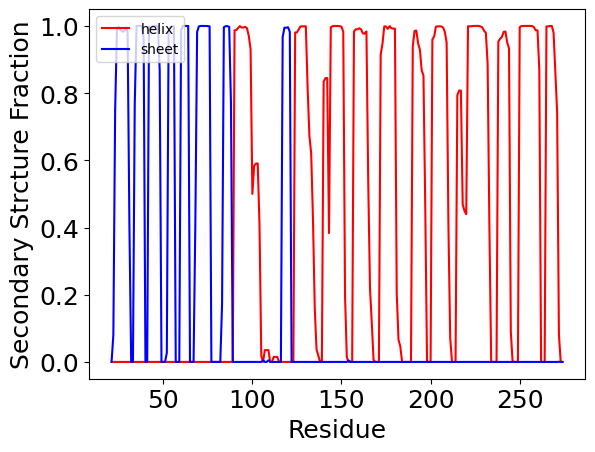

In [8]:
dssp=md.compute_dssp(traj_protein,simplified=True)

residue_num=[]
for res in traj_protein.topology.residues: 
    residue_num.append(res.resSeq)
residue_id=np.asarray(residue_num)
residue_id

def dssp_convert(dssp):
 dsspH=np.copy(dssp)
 dsspE=np.copy(dssp)
 dsspH[dsspH=='H']=1                                                                                      
 dsspH[dsspH=='E']=0                                                                                      
 dsspH[dsspH=='C']=0                                                                                      
 dsspH[dsspH=='NA']=0 
 dsspH=dsspH.astype(int)
 TotalH=np.sum(dsspH,axis=1) 
 Hprop=np.sum(dsspH,axis=0).astype(float)/len(dsspE) 

 dsspE[dsspE=='H']=0
 dsspE[dsspE=='E']=1
 dsspE[dsspE=='C']=0
 dsspE[dsspE=='NA']=0
 dsspE=dsspE.astype(int)
 TotalE=np.sum(dsspE,axis=1) 
 Eprop=np.sum(dsspE,axis=0).astype(float)/len(dsspE) 
 return Hprop, Eprop

Hprop,Eprop=dssp_convert(dssp)
plt.plot(residue_num,Hprop,c='r',label='helix')
plt.plot(residue_num,Eprop,c='b',label='sheet')

plt.legend(loc="upper left")
plt.xlabel('Residue', size=18)
plt.ylabel('Secondary Strcture Fraction', size=18)
plt.tick_params(labelsize=18)


In [9]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=residue_num, y=Hprop, mode='lines', name='helix', line=dict(color='red')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop, mode='lines', name='sheet', line=dict(color='blue')))
fig.update_layout(title='Secondary Structure Fractions',
                  xaxis_title='Residue',
                  yaxis_title='Secondary Structure Fraction',
                  legend=dict(x=0, y=1))

In [10]:
# dssp_full=md.compute_dssp(trj,simplified=False)

# def dssp_convert_type(dssp,type):
#  dsspS=np.copy(dssp)
#  dsspS[dsspS!=type]=0                                                                                      
#  dsspS[dsspS==type]=1                                                                                      
#  dsspS=dsspS.astype(int)
#  TotalS=np.sum(dsspS,axis=1) 
#  Sprop=np.sum(dsspS,axis=0).astype(float)/len(dsspS) 
#  return Sprop

# for t in ['H','E','I','G','B','T','S',' ']:
#   Tprop=dssp_convert_type(dssp_full,t)
#   plt.plot(residue_num,Tprop,label=t)
#   print("SS:",t,np.asarray(residue_num)[np.where(Tprop>.90)])

# plt.legend(loc="upper left")
# plt.xlabel('Residue', size=18)
# plt.ylabel('Secondary Strcture Fraction', size=18)
# plt.tick_params(labelsize=18)


In [11]:
# #Find all the frames where a given residue is H or E
# residue_number=39
# array_index=residue_number-0
# print(np.asarray(residue_num)[array_index])
# helix_frames=np.where(dssp[:,array_index]=='H')[0]
# beta_frames=np.where(dssp[:,array_index]=='E')[0]

# print("Residue %s"%np.asarray(residue_num)[array_index])
# print("helix frames:",len(helix_frames),helix_frames)
# print("beta frames:",len(beta_frames),beta_frames)

In [12]:
indices_phi, phis = md.compute_phi(traj_protein)
indices_psi, psis = md.compute_psi(traj_protein)
indices_chi1, chi1s = md.compute_chi1(traj_protein)
indices_chi2, chi2s = md.compute_chi2(traj_protein)

In [13]:
phi_dict={}
dihedral_dict = { 'phi': { },
          'psi': { },
          'chi1': { },
          'chi2': { }}

for i in range(0,len(indices_phi)):
  indices=indices_phi[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['phi'][resnum]=phis[:,i]

for i in range(0,len(indices_psi)):
  indices=indices_psi[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['psi'][resnum]=psis[:,i]

for i in range(0,len(indices_chi1)):
  indices=indices_chi1[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['chi1'][resnum]=chi1s[:,i]

for i in range(0,len(indices_chi2)):
  indices=indices_chi2[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['chi2'][resnum]=chi2s[:,i]

In [14]:
sequence

' [ASN21, ASN22, MET23, LEU24, VAL25, LEU26, LYS27, LYS28, ILE29, ARG30, PHE31, TYR32, ASN33, CYS34, ALA35, ILE36, ILE37, HIS38, LEU39, ARG40, ASP41, ALA42, GLN43, LEU44, LEU45, ILE46, ARG47, THR48, LYS49, ASP50, GLY51, GLN52, THR53, LEU54, ASN55, ILE56, PRO57, PRO58, GLU59, SER60, LEU61, CYS62, TYR63, VAL64, GLU65, LYS66, ASN67, THR68, VAL69, MET70, ASP71, VAL72, ALA73, LEU74, LYS75, VAL76, LEU77, GLY78, SER79, GLY80, VAL81, PRO82, TYR83, GLU84, VAL85, TYR86, HIS87, VAL88, ASP89, SER90, ASP91, VAL92, LEU93, ARG94, CYS95, ILE96, CYS97, LYS98, VAL99, MET100, GLU101, PRO102, LEU103, LEU104, LEU105, ASP106, PRO107, GLN108, ARG109, VAL110, ASN111, HIS112, THR113, ARG114, ARG115, LYS116, ILE117, PHE118, THR119, CYS120, ALA121, VAL122, ASP123, GLU124, THR125, ASP126, THR127, ARG128, ILE129, PHE130, LYS131, ARG132, LEU133, THR134, GLY135, SER136, ASN137, VAL138, PRO139, GLN140, HIS141, ARG142, LEU143, VAL144, TYR145, LYS146, ILE147, THR148, TYR149, LEU150, LEU151, SER152, LYS153, VAL154, ASN1

In [15]:
#Heres a function to plot a phi/psi ramachandran plot:

def plot_phipsi(res):
 plt.hist2d(dihedral_dict['phi'][res],dihedral_dict['psi'][res],bins=36,range=[[-3.14,3.14],[-3.14,3.14]], norm=colors.LogNorm(),cmap='jet')
 plt.xlabel('$\phi$', size=18)
 plt.ylabel('$\psi$', size=18)
 plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
 plt.yticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
 plt.tick_params(labelsize=18)
 plt.show()
 return

def plot_chi(res):
    if res in dihedral_dict['chi1']:
     plt.hist(dihedral_dict['chi1'][res],bins=36,range=[-3.14,3.14])        
     plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.xlabel('$\chi_1$', size=18)
     plt.ylabel('counts', size=18)
     plt.tick_params(labelsize=18)
     plt.show()
     plt.clf()   
    if res in dihedral_dict['chi2']:
     plt.hist2d(dihedral_dict['chi1'][res],dihedral_dict['chi2'][res],bins=36,range=[[-3.14,3.14],[-3.14,3.14]], norm=colors.LogNorm(),cmap='jet')
     plt.xlabel('$\chi_1$', size=18)
     plt.ylabel('$\chi_2$', size=18)
     plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.yticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.tick_params(labelsize=18)
     plt.show()
    return




<>:5: SyntaxWarning:

invalid escape sequence '\p'

<>:6: SyntaxWarning:

invalid escape sequence '\p'

<>:17: SyntaxWarning:

invalid escape sequence '\c'

<>:24: SyntaxWarning:

invalid escape sequence '\c'

<>:25: SyntaxWarning:

invalid escape sequence '\c'

<>:5: SyntaxWarning:

invalid escape sequence '\p'

<>:6: SyntaxWarning:

invalid escape sequence '\p'

<>:17: SyntaxWarning:

invalid escape sequence '\c'

<>:24: SyntaxWarning:

invalid escape sequence '\c'

<>:25: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_20844/399539292.py:5: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_20844/399539292.py:6: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_20844/399539292.py:17: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_20844/399539292.py:24: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_20844/399539292.py:25: SyntaxWarning:

invalid escape sequence '\c'



In [16]:
traj_protein.time

array([1.0000e+05, 1.0010e+05, 1.0020e+05, ..., 2.1998e+06, 2.1999e+06,
       2.2000e+06], shape=(21001,), dtype=float32)

<>:13: SyntaxWarning:

invalid escape sequence '\A'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\A'

<>:13: SyntaxWarning:

invalid escape sequence '\A'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\A'

/tmp/ipykernel_20844/1701788557.py:13: SyntaxWarning:

invalid escape sequence '\A'

/tmp/ipykernel_20844/1701788557.py:14: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_20844/1701788557.py:20: SyntaxWarning:

invalid escape sequence '\A'



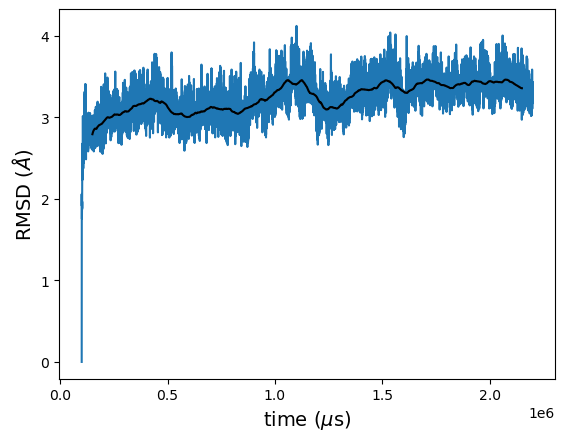

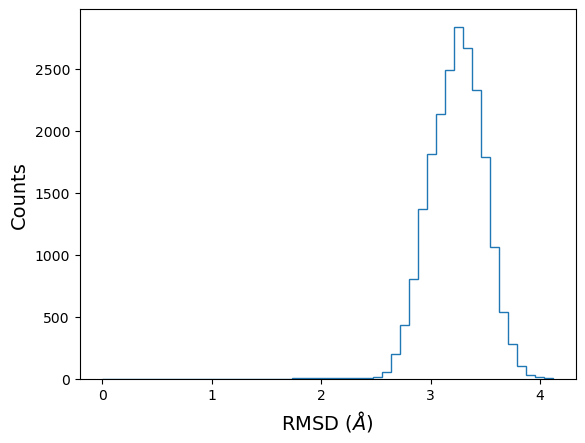

In [17]:
#Lets Calculate the RMSD and make a histogram from the starting structure 
def window_average(x, N):
    return np.convolve(x, np.ones(N)/N, mode='valid')

time=traj_protein.time
rmsd = md.rmsd(traj_protein, traj_protein, 0)

window_rmsd = window_average(rmsd*10, 1000)
window_time = window_average(time, 1000)

plt.plot(time,rmsd*10)
plt.plot(window_time,window_rmsd, c='k')
plt.ylabel('RMSD ($\AA$)',size=14);
plt.xlabel('time ($\mu$s)',size=14)
plt.show()
plt.clf()

plt.hist(rmsd*10,histtype='step',bins=50)
plt.ylabel('Counts',size=14);
plt.xlabel('RMSD ($\AA$)',size=14)
plt.show()

In [18]:
select_CA = traj_protein.topology.select('name CA')
select_BB = traj_protein.topology.select('backbone and not type H')
select_sidechains = traj_protein.topology.select('sidechain and not type H')
select_DBD = traj_protein.topology.select('resid 172 to 274')
select_cupin = traj_protein.topology.select('resid 1 to 88 or resid 113 to 122')
select_dimer_interface = traj_protein.topology.select('resid 90 to 103 or resid 123 to 153')
rmsd_CA = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_CA)
rmsd_BB = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_BB)
rmsd_sidechains = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_sidechains)
rmsd_DBD = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_DBD)
rmsd_cupin = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_cupin)
rmsd_dimer_interface = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_dimer_interface)

Text(0.5, 1.0, 'Sidechains')

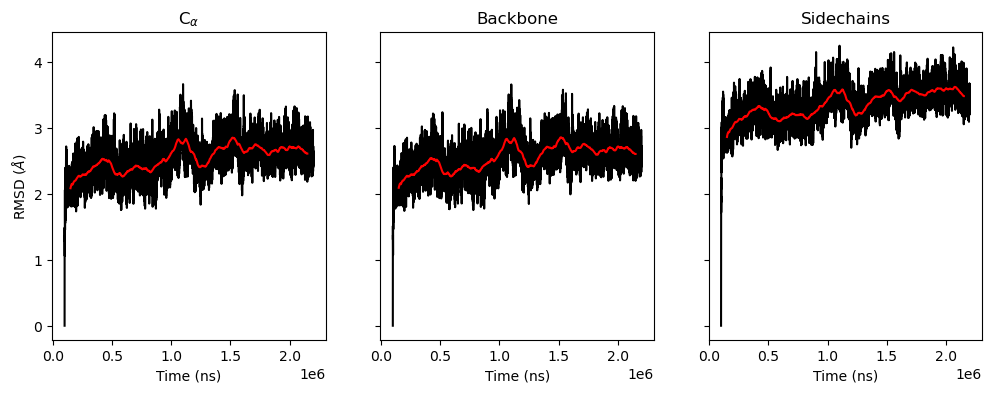

In [19]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))

# C Alphas 
ax[0].plot(time, rmsd_CA*10, c='k')
ax[0].plot(window_average(time, 1000), window_average(rmsd_CA*10,1000), c='r')
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title(r'C$_\alpha$')

# Backbone
ax[1].plot(time, rmsd_BB*10, c='k')
ax[1].plot(window_average(time, 1000), window_average(rmsd_BB*10,1000), c='r')
ax[1].set_xlabel('Time (ns)')
ax[1].set_title('Backbone')

# Sidechains
ax[2].plot(time, rmsd_sidechains*10, c='k')
ax[2].plot(window_average(time, 1000), window_average(rmsd_sidechains*10,1000), c='r')
ax[2].set_xlabel('Time (ns)')
ax[2].set_title('Sidechains')

Text(0.5, 1.0, 'Dimerization Interface')

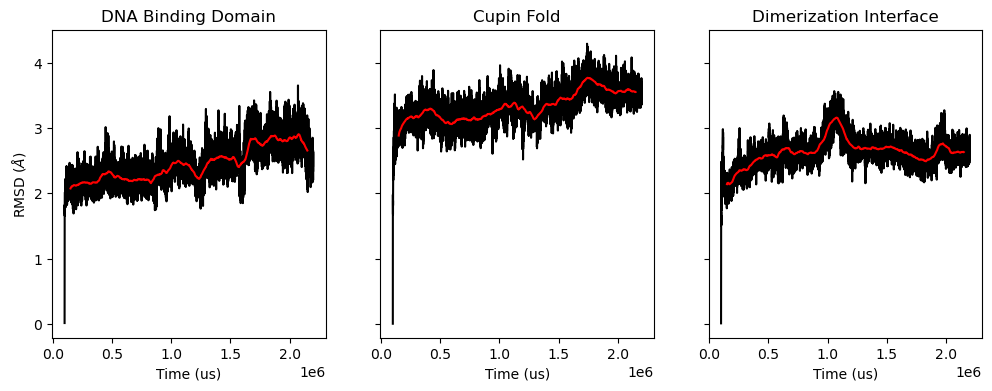

In [20]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))

# DNA Binding Domain 
ax[0].plot(time, rmsd_DBD*10, c='k')
ax[0].plot(window_average(time, 1000), window_average(rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Time (us)')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time, rmsd_cupin*10, c='k')
ax[1].plot(window_average(time, 1000), window_average(rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Time (us)')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time, rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time, 1000), window_average(rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Time (us)')
ax[2].set_title('Dimerization Interface')

<>:9: SyntaxWarning:

invalid escape sequence '\m'

<>:9: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_20844/852894860.py:9: SyntaxWarning:

invalid escape sequence '\m'



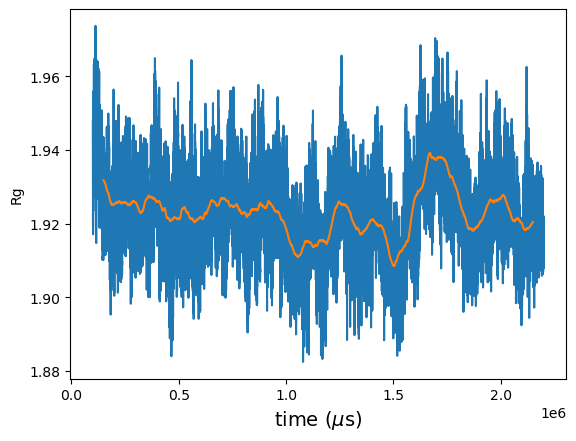

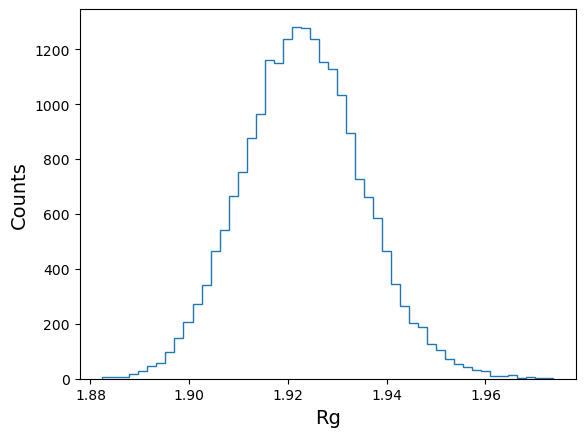

In [21]:
#Lets calculate the radius of gyration and make a histogram
rg=md.compute_rg(traj_protein, masses=None)

window_rg = window_average(rg, 1000)

plt.plot(time,rg)
plt.plot(window_time,window_rg)
plt.ylabel('Rg');
plt.xlabel('time ($\mu$s)',size=14)
plt.show()
plt.clf()

plt.hist(rg,histtype='step',bins=50)
plt.ylabel('Counts',size=14);
plt.xlabel('Rg',size=14)
plt.show()

In [22]:
#Lets identify subtantially populated hydrogen bonds
hbonds = md.baker_hubbard(traj_protein, periodic=False)
label = lambda hbond : '%s -- %s' % (traj_protein.topology.atom(hbond[0]), traj_protein.topology.atom(hbond[2]))
for hbond in hbonds:
    print(label(hbond))
    

ASN21-N -- ASN21-OD1
ASN21-N -- LYS274-O
ASN21-N -- ASN21-OD1
ASN21-N -- LYS274-O
ASN21-N -- ASN21-OD1
ASN21-N -- LYS274-O
ASN22-N -- LYS274-O
ASN22-N -- LYS274-OXT
ASN22-ND2 -- LEU270-O
ASN22-ND2 -- LYS273-O
MET23-N -- ASN22-OD1
LEU24-N -- LEU74-O
LEU26-N -- VAL72-O
LYS28-N -- ASP71-OD1
LYS28-N -- ASP71-OD2
ILE29-N -- MET70-O
ARG30-N -- TYR225-OH
ARG30-NE -- ASP221-OD1
ARG30-NE -- ASP221-OD2
ARG30-NH2 -- ASP221-OD1
ARG30-NH2 -- ASP221-OD2
PHE31-N -- THR68-O
ASN33-ND2 -- VAL88-O
ASN33-ND2 -- GLU174-OE2
ALA35-N -- VAL64-O
ILE36-N -- TYR86-O
ILE37-N -- CYS62-O
HIS38-N -- GLU84-O
HIS38-NE2 -- THR127-OG1
LEU39-N -- SER60-O
ARG40-NE -- ASP41-OD1
ARG40-NE -- ASP41-OD2
ARG40-NH1 -- GLU124-OE1
ARG40-NH1 -- GLU124-OE2
ARG40-NH2 -- ASP41-OD1
ARG40-NH2 -- ASP41-OD2
ARG40-NH2 -- GLU124-OE1
ARG40-NH2 -- GLU124-OE2
GLN43-N -- LYS75-O
GLN43-NE2 -- ASN55-OD1
LEU44-N -- ILE56-O
LEU45-N -- ALA73-O
ILE46-N -- LEU54-O
ARG47-N -- ASP71-O
ARG47-NH1 -- THR53-OG1
THR48-N -- GLN52-O
LYS49-N -- VAL69-O
ASP50-N 

In [23]:
for hbond in hbonds:
 donor = top.atom(hbond[0])
 acc = top.atom(hbond[2])
 print(hbond,donor,acc)

[ 0  1 10] ASN21-N ASN21-OD1
[   0    1 4196] ASN21-N LYS274-O
[ 0  2 10] ASN21-N ASN21-OD1
[   0    2 4196] ASN21-N LYS274-O
[ 0  3 10] ASN21-N ASN21-OD1
[   0    3 4196] ASN21-N LYS274-O
[  16   17 4196] ASN22-N LYS274-O
[  16   17 4197] ASN22-N LYS274-OXT
[  25   26 4114] ASN22-ND2 LEU270-O
[  25   26 4174] ASN22-ND2 LYS273-O
[30 31 24] MET23-N ASN22-OD1
[ 47  48 895] LEU24-N LEU74-O
[ 82  83 866] LEU26-N VAL72-O
[123 124 847] LYS28-N ASP71-OD1
[123 124 848] LYS28-N ASP71-OD2
[145 146 838] ILE29-N MET70-O
[ 164  165 3386] ARG30-N TYR225-OH
[ 177  178 3309] ARG30-NE ASP221-OD1
[ 177  178 3310] ARG30-NE ASP221-OD2
[ 183  184 3309] ARG30-NH2 ASP221-OD1
[ 183  184 3310] ARG30-NH2 ASP221-OD2
[188 189 805] PHE31-N THR68-O
[ 238  239 1113] ASN33-ND2 VAL88-O
[ 238  239 2521] ASN33-ND2 GLU174-OE2
[254 255 740] ALA35-N VAL64-O
[ 264  265 1080] ILE36-N TYR86-O
[283 284 703] ILE37-N CYS62-O
[ 302  303 1043] HIS38-N GLU84-O
[ 313  314 1741] HIS38-NE2 THR127-OG1
[319 320 673] LEU39-N SER60-O
[351

In [24]:
# Hbond_index=4
# hbond=hbonds[Hbond_index]
# donor = top.atom(hbond[0])
# acc = top.atom(hbond[2])
# print(hbond,donor,acc)

# da_distance = md.compute_distances(trj, [[hbond[0],hbond[2]]], periodic=False)
# plt.hist(da_distance,histtype='step',bins=20, label=label(hbonds[Hbond_index]))
# #for i in [2, 3, 4]:
# #    plt.hist(da_distances[:, i], color=next(color),histtype='step',bins=10, label=label(hbonds[i]), alpha=0.5)
# plt.legend()
# plt.ylabel('Freq',size=14);
# plt.xlabel('Donor-acceptor distance [nm]',size=14)
# plt.show()

***We're going to run a Principle Component Analysis (PCA)***

This takes the variance of the cartesian coordinates of each atom over the course of the trajectory and finds "projections" that explain as much of variance as posisble.

https://en.wikipedia.org/wiki/Principal_component_analysis

In [25]:
idx_selector = np.triu_indices(len(select_CA), k=1)
idx_selector

(array([  0,   0,   0, ..., 251, 251, 252], shape=(32131,)),
 array([  1,   2,   3, ..., 252, 253, 253], shape=(32131,)))

In [26]:
CA_pairs = np.stack([select_CA[idx_selector[0].tolist()], select_CA[idx_selector[1].tolist()]]).T

In [27]:
Ca_distances = md.compute_distances(traj_protein, CA_pairs, periodic=True)

In [28]:
# Ca PCA
pca_ca = PCA(n_components=2)
pca_ca.fit(Ca_distances)
Ca_distances_pca = pca_ca.transform(Ca_distances)
print(Ca_distances_pca.shape)

# Cartesian PCA
pca1 = PCA(n_components=2)
traj_protein.superpose(traj_protein, 0)
reduced_cartesian = pca1.fit_transform(traj_protein.xyz.reshape(traj_protein.n_frames, traj_protein.n_atoms * 3))
print(reduced_cartesian.shape)

(21001, 2)
(21001, 2)


<>:18: SyntaxWarning:

invalid escape sequence '\m'

<>:18: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_20844/456197298.py:18: SyntaxWarning:

invalid escape sequence '\m'



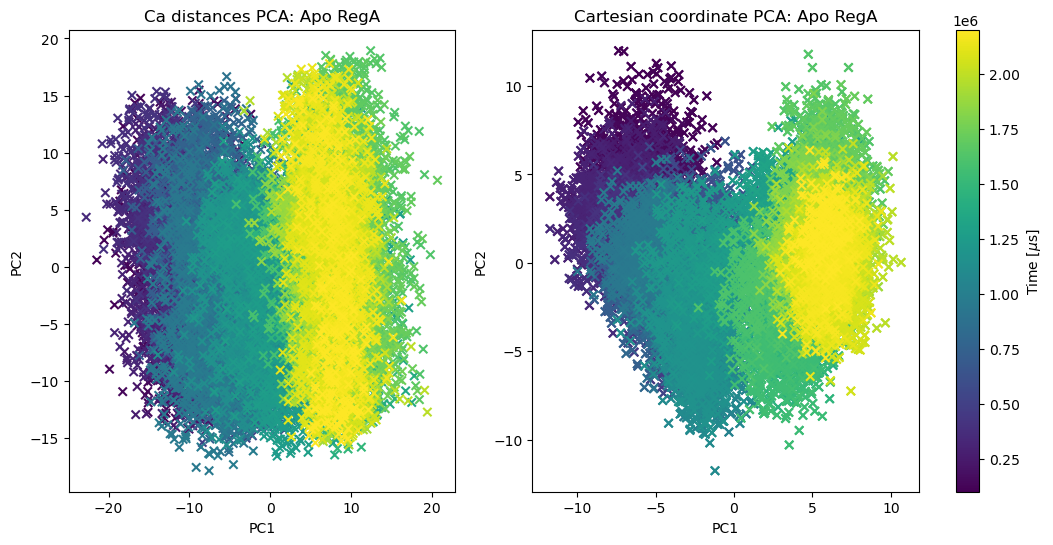

In [29]:
#We Can plot each frame as a function of the values of each PC(principal component): PC1 and PC2

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].scatter(Ca_distances_pca[:, 0], Ca_distances_pca[:,1], marker='x', c=time)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2') 
ax[0].set_title('Ca distances PCA: Apo RegA')

ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=time)
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2') 
ax[1].set_title('Cartesian coordinate PCA: Apo RegA')

# Add colorbar for the right scatter plot (ax[1])
sc = ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=time)
cbar = plt.colorbar(sc, ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Time [$\mu$s]')

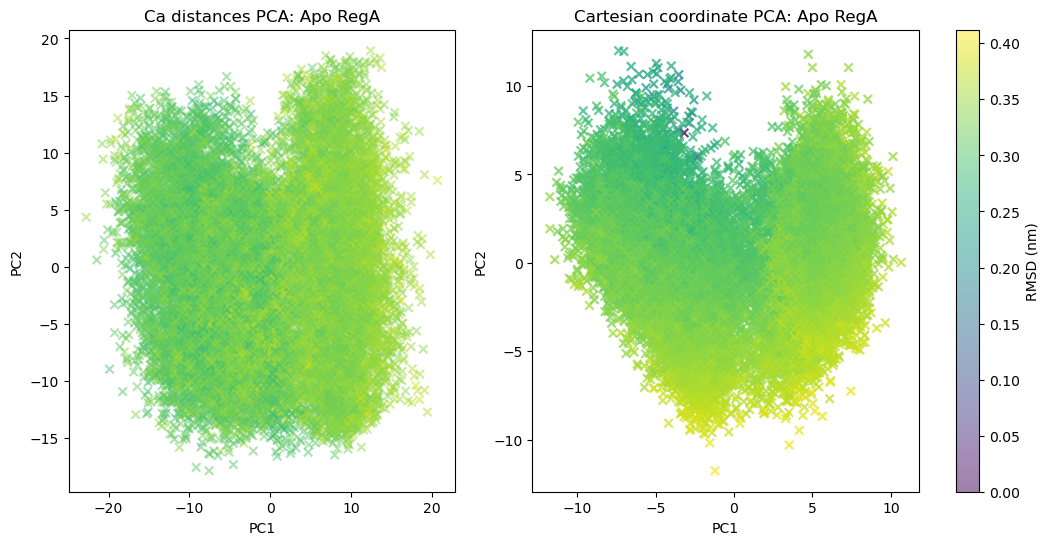

In [30]:
#We Can plot each frame as a function of the values of each PC(principal component): PC1 and PC2

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].scatter(Ca_distances_pca[:, 0], Ca_distances_pca[:,1], marker='x', c=rmsd, alpha=0.5)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2') 
ax[0].set_title('Ca distances PCA: Apo RegA')

ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=rmsd, alpha=0.5)
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2') 
ax[1].set_title('Cartesian coordinate PCA: Apo RegA')

# Add colorbar for the right scatter plot (ax[1])
sc = ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=rmsd, alpha=0.5)
cbar = plt.colorbar(sc, ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('RMSD (nm)')


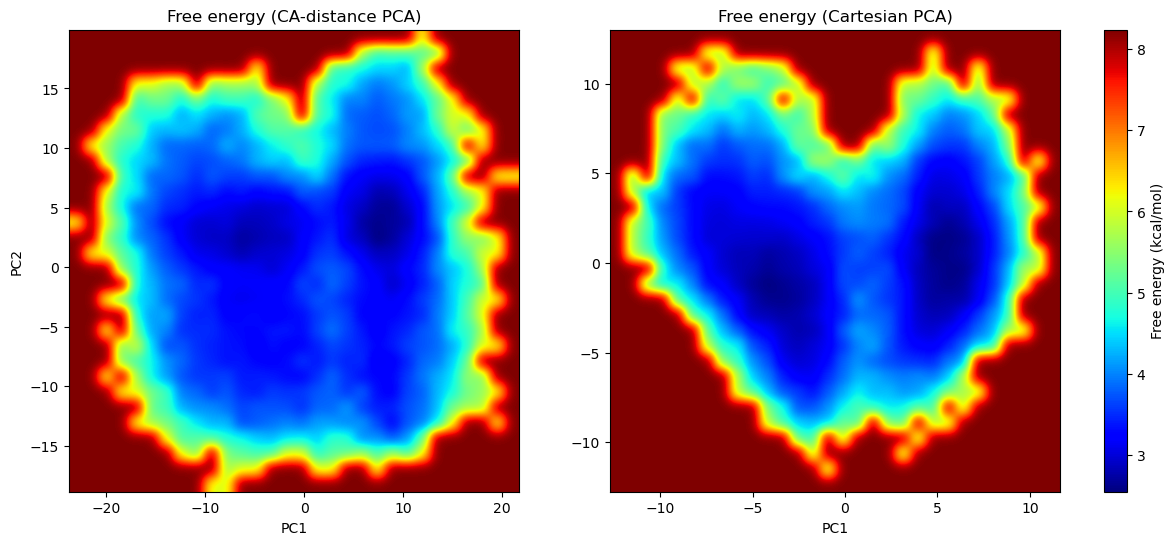

In [31]:
# Free energy plots for both CA-distance PCA and Cartesian PCA (side-by-side).
# This cell relies on variables computed in other cells:
# - Ca_distances_pca (from CA distances PCA)
# - reduced_cartesian (from Cartesian PCA)
# If the free_energy helper isn't defined yet (it exists in later cells), define a small fallback.

if 'free_energy' not in globals():
    def free_energy(a, b, T, y0, ymax, x0, xmax):
        free_energy, xedges, yedges = np.histogram2d(
            a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=None)
        free_energy = np.log(np.flipud(free_energy) + 1e-6)
        free_energy = -(0.001987 * T) * free_energy
        return free_energy, xedges, yedges

# Prepare PC pairs
PC1_ca, PC2_ca = Ca_distances_pca[:, 0], Ca_distances_pca[:, 1]
PC1_cart, PC2_cart = reduced_cartesian[:, 0], reduced_cartesian[:, 1]

# Set ranges with a small margin
def _range(v, margin=1.0):
    mn, mx = np.min(v), np.max(v)
    return mn - margin, mx + margin

y0_ca, ymax_ca = _range(PC2_ca)
x0_ca, xmax_ca = _range(PC1_ca)

y0_cart, ymax_cart = _range(PC2_cart)
x0_cart, xmax_cart = _range(PC1_cart)

# Compute free energies
dG_ca, xedges_ca, yedges_ca = free_energy(PC2_ca, PC1_ca, 300, y0_ca, ymax_ca, x0_ca, xmax_ca)
dG_cart, xedges_cart, yedges_cart = free_energy(PC2_cart, PC1_cart, 300, y0_cart, ymax_cart, x0_cart, xmax_cart)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

im0 = axes[0].imshow(dG_ca, interpolation='gaussian',
                     extent=[yedges_ca[0], yedges_ca[-1], xedges_ca[0], xedges_ca[-1]],
                     cmap='jet', aspect='auto')
axes[0].set_title('Free energy (CA-distance PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_xlim(np.min(PC1_ca)-1, np.max(PC1_ca)+1)
axes[0].set_ylim(np.min(PC2_ca)-1, np.max(PC2_ca)+1)

im1 = axes[1].imshow(dG_cart, interpolation='gaussian',
                     extent=[yedges_cart[0], yedges_cart[-1], xedges_cart[0], xedges_cart[-1]],
                     cmap='jet', aspect='auto')
axes[1].set_title('Free energy (Cartesian PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_xlim(np.min(PC1_cart)-1, np.max(PC1_cart)+1)
axes[1].set_ylim(np.min(PC2_cart)-1, np.max(PC2_cart)+1)

# Shared colorbar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Free energy (kcal/mol)')

In [ ]:
# Frames which correlate to the low free energy basin in the PC1 vs. PC2 plot.

basin1frames = np.where((PC1>-6) & (PC1<0) & (PC2>-6) & (PC2<1))
basin1frames = basin1frames[0]
print("Number of frames in basin 1:",len(basin1frames))

basin2frames = np.where((PC1>4) & (PC1<8) & (PC2>-5) & (PC2<5))
basin2frames = basin2frames[0]
print("Number of frames in basin 2:",len(basin2frames))

basin1trajectory = trj[basin1frames]
# basin1trajectory.save_xtc(f'/data/Jayde/Rega/Ligand/Basin_1_allatoms.xtc')

basin2trajectory = trj[basin2frames]
# basin2trajectory.save_xtc(f'/data/Jayde/Rega/Ligand/Basin_2_allatoms.xtc')

Number of frames in basin 1: 5922
Number of frames in basin 2: 6133


In [66]:
# basin1frames = np.where((PC1>-6) & (PC1<0) & (PC2>-6) & (PC2<1))
# basin1frames = basin1frames[0]
# print("Number of frames in basin 1:",len(basin1frames))

# basin2frames = np.where((PC1>4) & (PC1<8) & (PC2>-5) & (PC2<5))
# basin2frames = basin2frames[0]
# print("Number of frames in basin 2:",len(basin2frames))

# basin1trajectory = traj[basin1frames]
# basin1trajectory.save_xtc(f'/data/Jayde/Rega/Ligand/Basin_1.xtc')

# basin2trajectory = traj[basin2frames]
# basin2trajectory.save_xtc(f'/data/Jayde/Rega/Ligand/Basin_2.xtc')

In [27]:
Hprop_basin1,Eprop_basin1=dssp_convert(dssp[basin1frames])
Hprop_basin2,Eprop_basin2=dssp_convert(dssp[basin2frames])

fig = go.Figure()
fig.add_trace(go.Scatter(x=residue_num, y=Hprop_basin1, mode='lines', name='basin1 helix', line=dict(color='red')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop_basin1, mode='lines', name='basin1 sheet', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=residue_num, y=Hprop_basin2, mode='lines', name='basin2 helix', line=dict(color='green')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop_basin2, mode='lines', name='basin2 sheet', line=dict(color='orange')))
fig.update_layout(title='Secondary Structure Fractions per Basin',
                  xaxis_title='Residue',
                  yaxis_title='Secondary Structure Fraction',
                  legend=dict(x=0, y=1))

In [ ]:
atom_indices = [a.index for a in traj_protein.topology.atoms if a.element.symbol != 'H']
distances = np.empty((basin1trajectory.n_frames, basin1trajectory.n_frames))
for i in range(basin1trajectory.n_frames):
    distances[i] = md.rmsd(basin1trajectory, basin1trajectory, i, atom_indices=atom_indices)

distances_basin2 = np.empty((basin2trajectory.n_frames, basin2trajectory.n_frames))
for i in range(basin2trajectory.n_frames):
    distances_basin2[i] = md.rmsd(basin2trajectory, basin2trajectory, i, atom_indices=atom_indices)

beta = 1
index = np.exp(-beta*distances / distances.std()).sum(axis=1).argmax()
print(index)

centroid1 = basin1trajectory[index]
centroid1.save_pdb(f'/data/Jayde/Rega/Ligand/Basin_1_centroid.pdb')
print(centroid1)

centroid2 = basin2trajectory[index]
centroid2.save_pdb(f'/data/Jayde/Rega/Ligand/Basin_2_centroid.pdb')
print(centroid2)

1713
<mdtraj.Trajectory with 1 frames, 51351 atoms, 12045 residues, and unitcells>
<mdtraj.Trajectory with 1 frames, 51351 atoms, 12045 residues, and unitcells>


In [65]:
crystal_structure = md.load_pdb('/data/Jayde/Rega/RegA_Regacin_ChainB.pdb')
traj_basin1 = md.load('/data/Jayde/Rega/Ligand/Basin_1_allatoms.xtc', top='/data/Jayde/Rega/Ligand/Basin_1_centroid.pdb',stride=1)

crystal_indices = crystal_structure.topology.select('name CA')
crystal_structure_CA = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('backbone and not type H')
crystal_structure_BB = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('residue 0 to 252 and sidechain and not type H')
crystal_structure_sidechains = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('residue 172 to 273 and not water and not type H')
crystal_structure_DBD = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('(residue 1 to 88 or residue 113 to 122) and not water and not type H')
crystal_structure_cupin = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('(residue 90 to 103 or residue 123 to 153) and not water and not type H')
crystal_structure_dimer_interface = crystal_structure.atom_slice(crystal_indices)

basin1_select_CA = traj_basin1.topology.select('name CA and not type H')
basin1_select_BB = traj_basin1.topology.select('backbone and not type H')
basin1_select_sidechains = traj_basin1.topology.select('residue 0 to 252 and sidechain and not type H')
basin1_select_DBD = traj_basin1.topology.select('residue 172 to 273 and not type H and not water')
basin1_select_cupin = traj_basin1.topology.select('(residue 1 to 88 or residue 113 to 122) and not type H and not water')
basin1_select_dimer_interface = traj_basin1.topology.select('(residue 90 to 103 or residue 123 to 153) and not type H and not water')
basin1_rmsd_CA = md.rmsd(traj_basin1.atom_slice(basin1_select_CA), crystal_structure_CA)
basin1_rmsd_BB = md.rmsd(traj_basin1.atom_slice(basin1_select_BB), crystal_structure_BB)
basin1_rmsd_sidechains = md.rmsd(traj_basin1.atom_slice(basin1_select_sidechains), crystal_structure_sidechains)
basin1_rmsd_DBD = md.rmsd(traj_basin1.atom_slice(basin1_select_DBD), crystal_structure_DBD)
basin1_rmsd_cupin = md.rmsd(traj_basin1.atom_slice(basin1_select_cupin), crystal_structure_cupin)
basin1_rmsd_dimer_interface = md.rmsd(traj_basin1.atom_slice(basin1_select_dimer_interface), crystal_structure_dimer_interface)

In [66]:
traj_basin2 = md.load('/data/Jayde/Rega/Ligand/Basin_2_allatoms.xtc', top='/data/Jayde/Rega/Ligand/Basin_2_centroid.pdb',stride=1)

basin2_select_CA = traj_basin2.topology.select('name CA and not type H')
basin2_select_BB = traj_basin2.topology.select('backbone and not type H')
basin2_select_sidechains = traj_basin2.topology.select('residue 0 to 252 and sidechain and not type H')
basin2_select_DBD = traj_basin2.topology.select('residue 172 to 273 and not type H and not water')
basin2_select_cupin = traj_basin2.topology.select('(residue 1 to 88 or residue 113 to 122) and not type H and not water')
basin2_select_dimer_interface = traj_basin2.topology.select('(residue 90 to 103 or residue 123 to 153) and not type H and not water')
basin2_rmsd_CA = md.rmsd(traj_basin2.atom_slice(basin2_select_CA), crystal_structure_CA)
basin2_rmsd_BB = md.rmsd(traj_basin2.atom_slice(basin2_select_BB), crystal_structure_BB)
basin2_rmsd_sidechains = md.rmsd(traj_basin2.atom_slice(basin2_select_sidechains), crystal_structure_sidechains)
basin2_rmsd_DBD = md.rmsd(traj_basin2.atom_slice(basin2_select_DBD), crystal_structure_DBD)
basin2_rmsd_cupin = md.rmsd(traj_basin2.atom_slice(basin2_select_cupin), crystal_structure_cupin)
basin2_rmsd_dimer_interface = md.rmsd(traj_basin2.atom_slice(basin2_select_dimer_interface), crystal_structure_dimer_interface)

<>:7: SyntaxWarning:

invalid escape sequence '\m'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\m'

<>:7: SyntaxWarning:

invalid escape sequence '\m'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/3615543163.py:7: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/3615543163.py:14: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/3615543163.py:20: SyntaxWarning:

invalid escape sequence '\m'



Text(0.5, 1.0, 'Dimerization Interface')

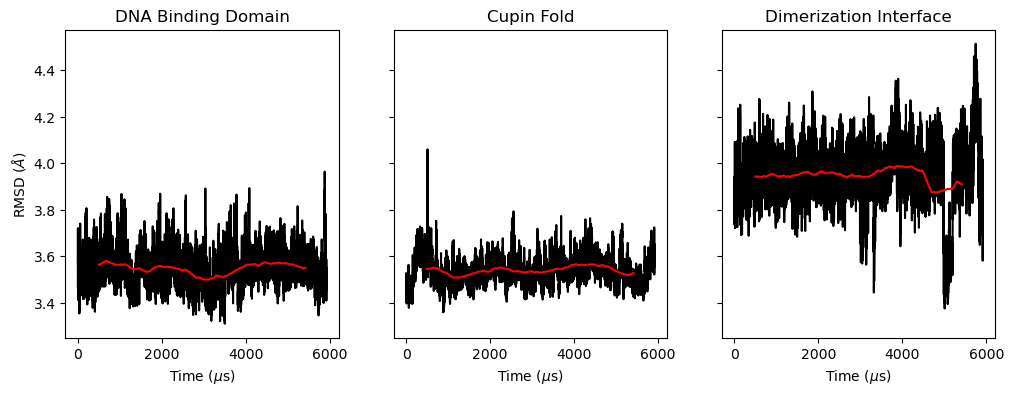

In [ ]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))
time_basin1 = np.arange(0, traj_basin1.n_frames)

# DNA Binding Domain 
ax[0].plot(time_basin1, basin1_rmsd_DBD*10, c='k')
ax[0].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Frames')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time_basin1, basin1_rmsd_cupin*10, c='k')
ax[1].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Frames')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time_basin1, basin1_rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Frames')
ax[2].set_title('Dimerization Interface')

<>:7: SyntaxWarning:

invalid escape sequence '\m'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\m'

<>:7: SyntaxWarning:

invalid escape sequence '\m'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/1300636522.py:7: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/1300636522.py:14: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1293097/1300636522.py:20: SyntaxWarning:

invalid escape sequence '\m'



Text(0.5, 1.0, 'Dimerization Interface')

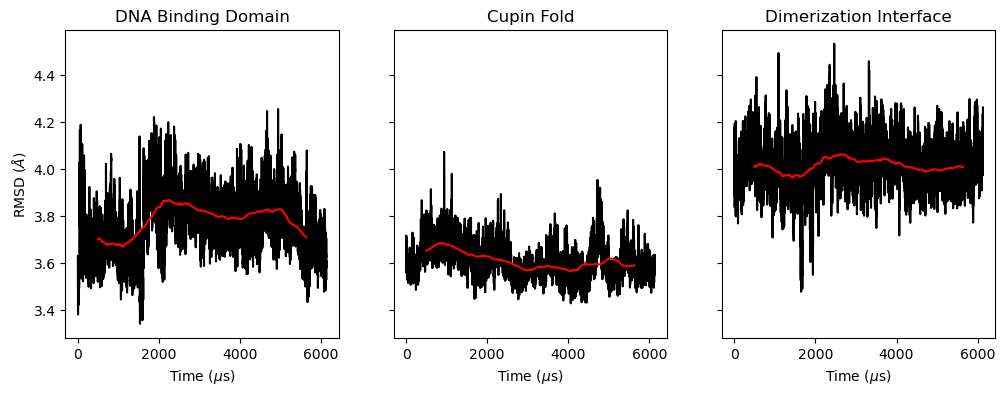

In [ ]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))
time_basin2 = np.arange(0, traj_basin2.n_frames)

# DNA Binding Domain 
ax[0].plot(time_basin2, basin2_rmsd_DBD*10, c='k')
ax[0].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Frames')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time_basin2, basin2_rmsd_cupin*10, c='k')
ax[1].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Frames')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time_basin2, basin2_rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Frames')
ax[2].set_title('Dimerization Interface')

In [ ]:
#Lets Calculate Some Correlation Times of Some Dihedral angles.
def autocorr1(x,lags):
    '''numpy.corrcoef, partial'''
    corr=[1. if l==0 else np.corrcoef(x[l:],x[:-l])[0][1] for l in lags]
    return np.array(corr)

#time in microseconds
time=np.linspace(0,1000,traj_protein.n_frames)


lags=range(10)
#C1C2bondlength[:,0]
phi2_acf=autocorr1(dihedral_dict['phi'][2],lags)
phi20_acf=autocorr1(dihedral_dict['phi'][20],lags)
chi20_acf=autocorr1(dihedral_dict['chi1'][20],lags)

plt.plot(time[lags],phi2_acf,color='b',label='phi_2')
plt.plot(time[lags],phi20_acf,color='r',label='phi_20')
plt.plot(time[lags],chi20_acf,color='g',label='chi1_20')

plt.legend()
plt.xlabel("Time ($\mu$s)", size=14, labelpad=15)
plt.ylabel("Autocorrelation", size=14, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(size='14')
plt.yticks(size='14')
plt.show()

<>:22: SyntaxWarning:

invalid escape sequence '\m'

<>:22: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1254585/1272716057.py:22: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_1254585/1272716057.py:22: SyntaxWarning:

invalid escape sequence '\m'



KeyError: 2

In [ ]:

def contact_map_avg(traj_protein, prot_len, cutoff=1.2):
    """
    Create average contact and distance maps for entire trajectory.
    Diagonal and self-distances are set to 0.
    
    :param trj: md.Trajectory object
    :param prot_len: number of residues
    :param cutoff: contact distance threshold in nm
    :return: (contact_map, distance_map) as (prot_len x prot_len) numpy arrays
    """
    # Generate unique residue pairs (i < j)
    pairs = [[i, j] for i in range(prot_len) for j in range(i+1, prot_len)]
    
    # Compute distances for all pairs across trajectory
    distances, _ = md.compute_contacts(traj_protein, pairs)
    
    # Initialize output matrices
    contact_map = np.zeros((prot_len, prot_len), dtype=float)
    distance_map = np.zeros((prot_len, prot_len), dtype=float)
    
    # Fill in values symmetrically
    for idx, (i, j) in enumerate(pairs):
        dist_ij = distances[:, idx]
        contact_ij = (dist_ij < cutoff).astype(int)

        if i==j:
            # Set diagonal and self-distances to 0
            contact_ij.fill(0)
            dist_ij.fill(0.0)

        avg_contact = np.mean(contact_ij)
        avg_distance = np.mean(dist_ij)

        contact_map[i, j] = contact_map[j, i] = avg_contact
        distance_map[i, j] = distance_map[j, i] = avg_distance

    return contact_map, distance_map
contact_map, distance_map = contact_map_avg(traj_protein[::5], prot_len=traj_protein.n_residues, cutoff=0.8)



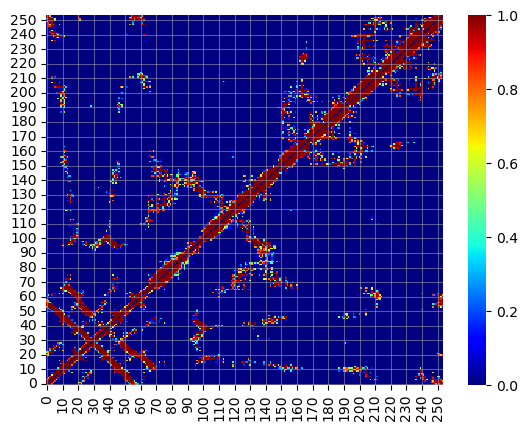

In [ ]:
ax = sns.heatmap(contact_map, vmin=0.0, vmax=1.0,cmap='jet')
ax.invert_yaxis()
ax.grid(which='both', alpha=0.5)


In [ ]:
# how to cluster 

from sklearn.cluster import KMeans

data = reduced_cartesian # or PCs of shape (n_frames, 2) 
n_clusters = 3 
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
kmeans.fit(data)
labels = kmeans.labels_
np.savetxt("kmeans_labels.txt", labels)

In [ ]:
kmeans.cluster_centers_

array([[-2.3666406 , -3.098614  ],
       [ 5.219185  ,  0.66397446],
       [-5.581015  ,  2.2751281 ]], dtype=float32)

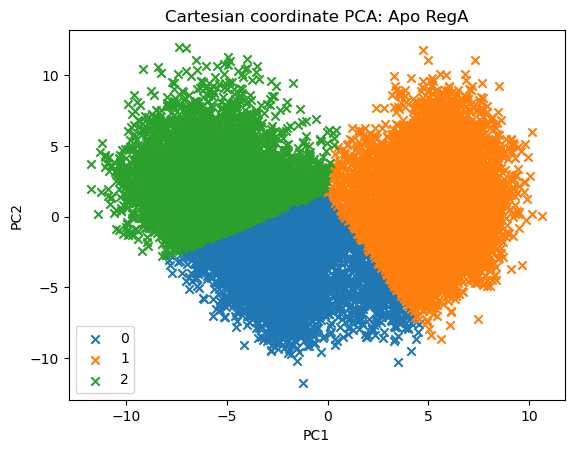

In [ ]:
plt.figure()
for i in np.unique(labels):
    plt.scatter(reduced_cartesian[:, 0][labels==i], reduced_cartesian[:,1][labels==i], marker='x', label=str(i))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cartesian coordinate PCA: Apo RegA')
plt.legend()

Lets think about some fun things we can do with this trajectory.  

Rubric (Completing the bolded tasks and attempting some additional tasks puts an assignment in the ~"P - B/B+" range, attempting and completing some additional more advanced tasks will earn a ~"HP - A/A-").  Very parital or incomplete attempts for the bolded questiosn is in the ~"LP / B-/C+"

Ideas:

**1.) Determine what is structural different about the "minor state" populated between 650-750us.  Can you make a visualization of the two states?** 

**2.)  Identify some dihedral angles that have very long correlation times? Can you your provide structural snapshots that explain why certain correlation times are longer?**

  More Advanced:
  
  2a) Can you calculate/ fit the correlation times? 
  
  2b) Can you write a loop to scan over all phi/psi/chi1/chi2 residues and identify residues with correlation times longer than a given threshold? 

3)Considering the minor state, can you find residues that have large changes in the distributions of backbone or sidechain dihedral angles?  Are there torsion angles with large differences in their correlation times between states?  Can you provide trajectory snapshots that explain why?

**4) Calculate the ciruclar correlation coefficients between phi and psi angles and reproduce the correlation map from below**  -Look into using a "mask" to eliminate some entries in the correlation matrix and make your plot prettier. 

5) Make a 2D map showing the populations of hydrogen bonds between different residues.

6) Compare the contact maps, dihedral correlations, and hydrogen bond populations between the major and minor states.

7) Compare the contact maps, dihedral correlations, and hydrogen bond populations for different subsets of PC space (ie PC1 is on the intevral [lower1,upper1] and PC2 is on the invertval [lower2,upper2]

7) Compute an visualize all-to-all RMSD calculation of the frames of this trajectory.  

8) Cluster the conformations of the trajectory in some way.  Perhaps consider using the all-to-all rmsd distances, or the the values of PCs.  (Consult https://mdtraj.org/1.9.4/examples/clustering.html or https://mdtraj.org/1.9.4/examples/centroids.html for examples)


9) Visualize the most populated clusters from your clustering analysis

Here is the equation used to calculate circular correlation coefficients for dihedral angles

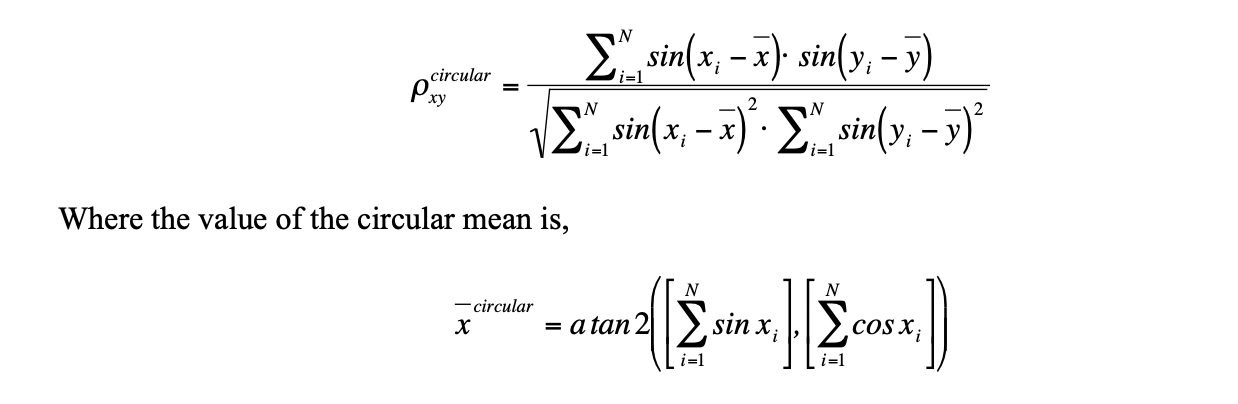


Lets calculate some correlations between dihedrals found in the paper: 


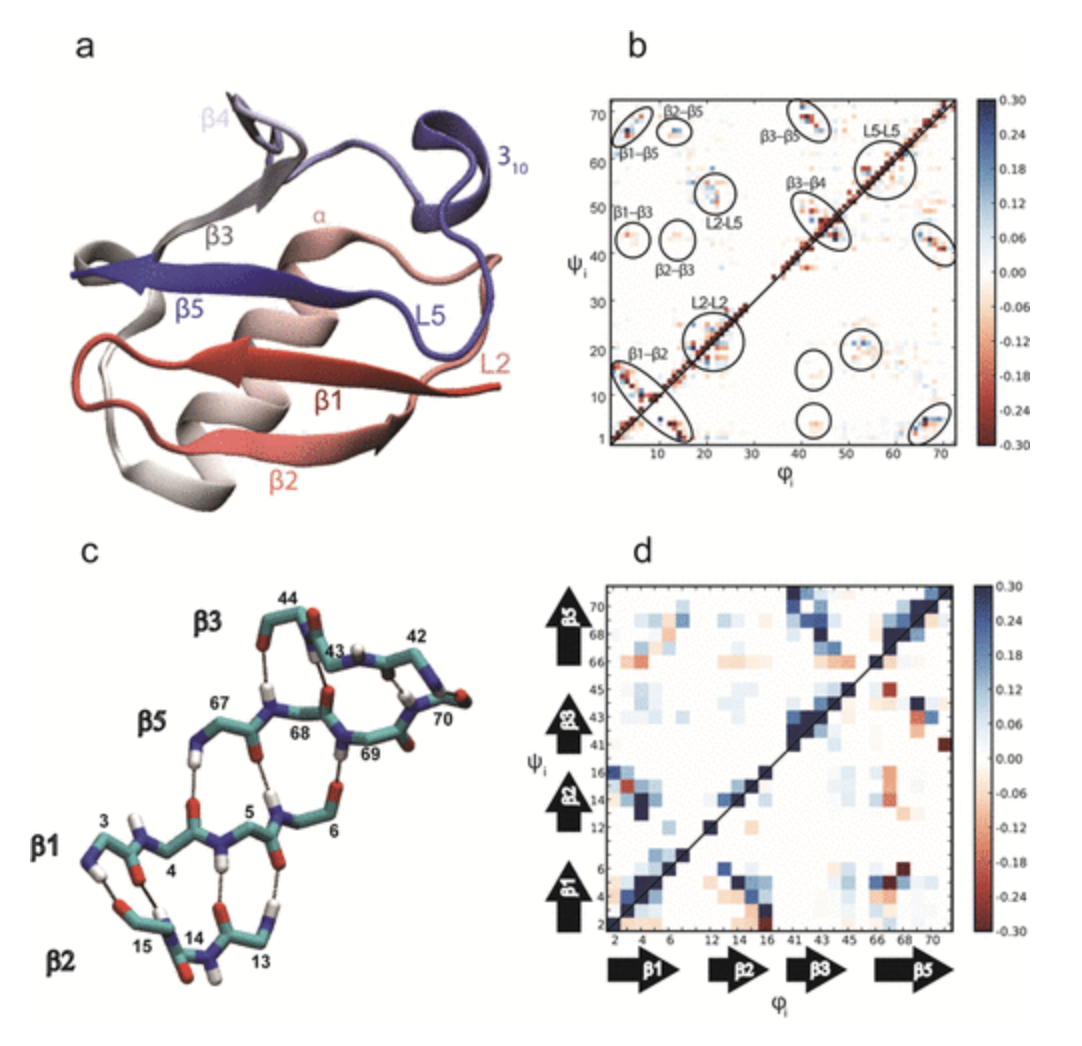